In [2]:
from sklearn.datasets import load_iris

In [10]:
iris = load_iris()
type(iris)

sklearn.utils._bunch.Bunch

In [4]:
for key in iris.keys():
    print(key)

data
target
frame
target_names
DESCR
feature_names
filename
data_module


In [5]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
print(iris.data.shape)

(150, 4)


In [7]:
import pandas as pd

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
iris_df = load_iris(as_frame=True).frame
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.2,
    random_state=42,
    stratify=iris.target
)

print(f"训练集特征形状: {X_train.shape}")
print(f"训练集标签形状: {y_train.shape}")
print(f"测试集特征形状: {X_test.shape}")
print(f"测试集标签形状: {y_test.shape}")

训练集特征形状: (120, 4)
训练集标签形状: (120,)
测试集特征形状: (30, 4)
测试集标签形状: (30,)


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"原始训练集 - 最小值: {X_train.min():.2f}, 最大值: {X_train.max():.2f}")
print(f"缩放后训练集 - 最小值: {X_train_scaled.min():.2f}, 最大值: {X_train_scaled.max():.2f}")

原始训练集 - 最小值: 0.10, 最大值: 7.90
缩放后训练集 - 最小值: 0.00, 最大值: 1.00


In [16]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_ss = sc.fit_transform(X_train)
X_test_ss = sc.transform(X_test)

print(f"原始训练集 - 均值: {X_train.mean():.2f}, 标准差: {X_train.std():.2f}")
print(f"缩放后训练集 - 均值: {X_train_ss.mean():.2f}, 标准差: {X_train_ss.std():.2f}")

原始训练集 - 均值: 3.47, 标准差: 1.97
缩放后训练集 - 均值: -0.00, 标准差: 1.00


In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_train_scaled)

X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"原始训练集形状: {X_train_scaled.shape}")
print(f"PCA后训练集形状: {X_train_pca.shape}")

print(f"方差解释比例: {pca.explained_variance_ratio_}")
print(f"累计方差解释比例: {pca.explained_variance_ratio_.cumsum()}")

原始训练集形状: (120, 4)
PCA后训练集形状: (120, 2)
方差解释比例: [0.83764035 0.12058745]
累计方差解释比例: [0.83764035 0.95822779]


In [25]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

iris = load_iris()
iris_data = iris.data
iris_target = iris.target

scaler = MinMaxScaler()
iris_scaled = scaler.fit_transform(iris_data)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(iris_scaled)

print(f"聚类中心:\n{kmeans.cluster_centers_}")
print(f"聚类标签:\n{kmeans.labels_}")
print(f"真实标签:\n{iris_target}")

print(f"样本到所属聚类中心的距离平方和: {kmeans.inertia_:.2f}")
print(f"实际迭代次数: {kmeans.n_iter_}")

聚类中心:
[[0.66773504 0.44310897 0.7571708  0.78205128]
 [0.19611111 0.595      0.07830508 0.06083333]
 [0.41203704 0.27690972 0.55896893 0.52083333]]
聚类标签:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 2 0 0 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 2 0 0 0 0 0
 0 0]
真实标签:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
样本到所属聚类中心的距离平方和: 7.12
实际迭代次数: 3


In [26]:
new_samples = [
    [1.5, 1.5, 1.5, 1.5],   # 较小尺寸
    [6.5, 3.0, 5.2, 2.0],   # 较大尺寸
    [6.3, 2.5, 5.0, 1.9]    # 较大尺寸
]
new_samples_scaled = scaler.transform(new_samples)

new_samples_labels = kmeans.predict(new_samples_scaled)
print(f"新样本的聚类标签: {new_samples_labels}")

新样本的聚类标签: [1 0 0]


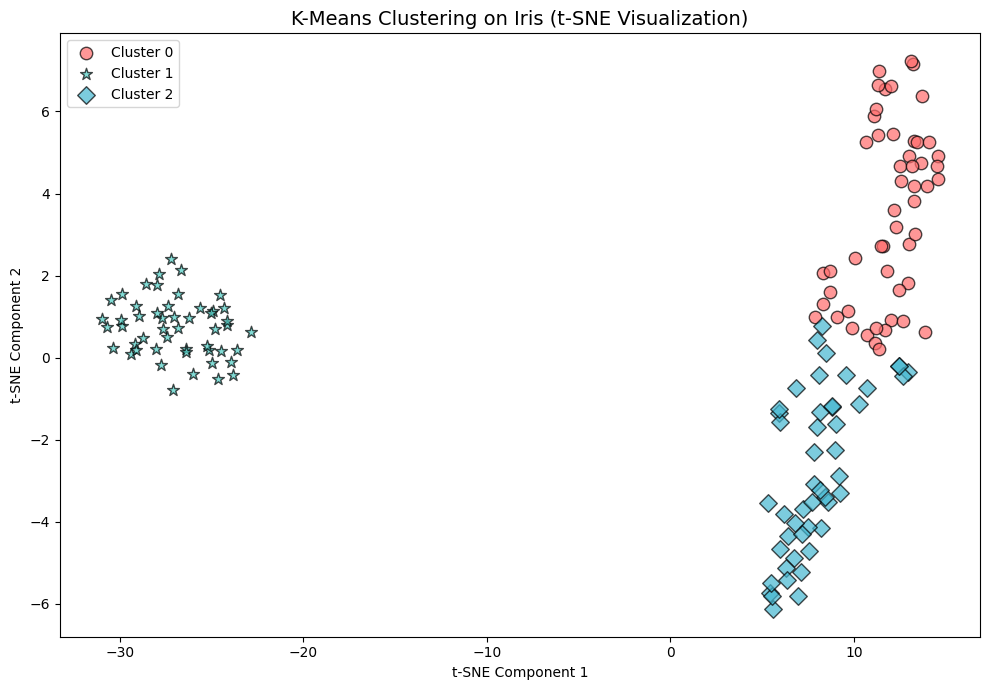

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 用 t-SNE 降到 2 维
tsne = TSNE(n_components=2, random_state=123)
iris_2d = tsne.fit_transform(iris_scaled)

# 整理成 DataFrame 方便操作
df_plot = pd.DataFrame(iris_2d, columns=['x', 'y'])
df_plot['cluster'] = kmeans.labels_

# 分组绘图
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
markers = ['o', '*', 'D']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    subset = df_plot[df_plot['cluster'] == i]
    ax.scatter(subset['x'], subset['y'], 
               c=colors[i], marker=markers[i], s=80,
               label=labels[i], alpha=0.7, edgecolors='black')

ax.set_title('K-Means Clustering on Iris (t-SNE Visualization)', fontsize=14)
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.legend()
plt.tight_layout()
plt.show()

K=2: 轮廓系数 = 0.6300
K=3: 轮廓系数 = 0.5048
K=4: 轮廓系数 = 0.4451
K=5: 轮廓系数 = 0.3507
K=6: 轮廓系数 = 0.3525
K=7: 轮廓系数 = 0.3380
K=8: 轮廓系数 = 0.3299
K=9: 轮廓系数 = 0.3412
K=10: 轮廓系数 = 0.3550
K=11: 轮廓系数 = 0.3408
K=12: 轮廓系数 = 0.3261
K=13: 轮廓系数 = 0.3319
K=14: 轮廓系数 = 0.3299


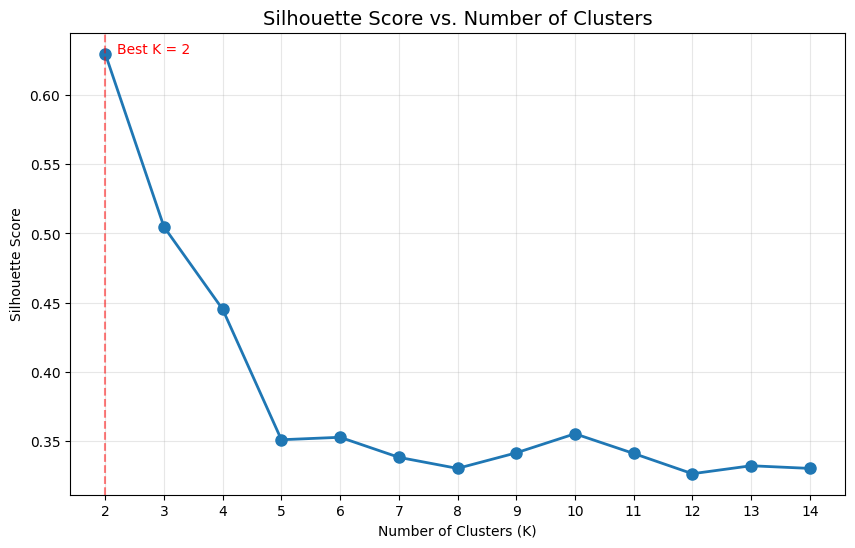

In [32]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=123)
    km.fit(iris_scaled)
    score = silhouette_score(iris_scaled, km.labels_)
    scores.append(score)
    print(f"K={k}: 轮廓系数 = {score:.4f}")

# 可视化
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), scores, marker='o', linewidth=2, markersize=8)
plt.title('Silhouette Score vs. Number of Clusters', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(alpha=0.3)
plt.xticks(list(k_range))

# 标注最优 K
best_k = list(k_range)[scores.index(max(scores))]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.5)
plt.text(best_k + 0.2, max(scores), f'Best K = {best_k}', color='red')
plt.show()

In [33]:
from sklearn.metrics import calinski_harabasz_score

print("=" * 50)
print(f"{'K值':^8} | {'CH 指数':^15}")
print("=" * 50)

for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=123)
    km.fit(iris_scaled)
    score = calinski_harabasz_score(iris_scaled, km.labels_)
    print(f"{k:^8} | {score:^15.4f}")

   K值    |      CH 指数     
   2     |    354.3656    
   3     |    359.8451    
   4     |    314.4730    
   5     |    288.8795    
   6     |    273.2730    
   7     |    258.6170    


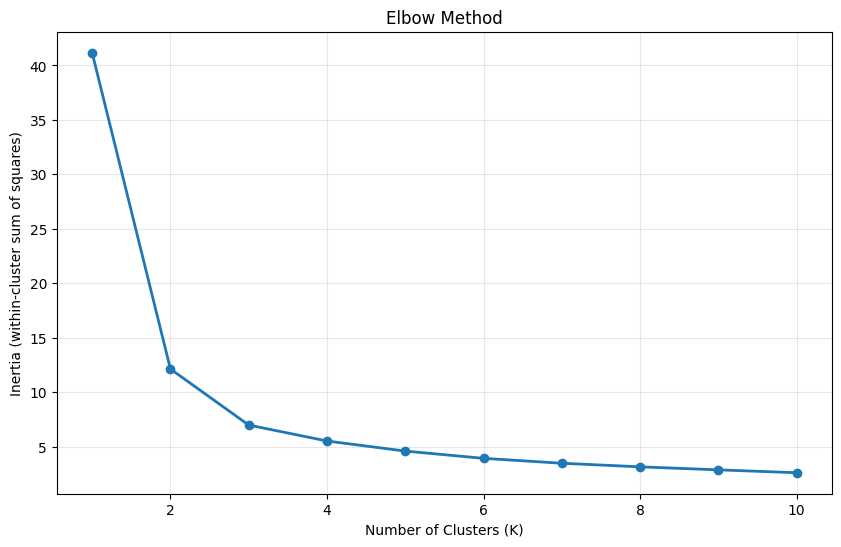

In [34]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=123)
    km.fit(iris_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertias, marker='o', linewidth=2)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.grid(alpha=0.3)
plt.show()

STEP 1: 加载并探索数据
数据形状: (150, 4)
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名称: ['setosa' 'versicolor' 'virginica']
各类样本数: [50 50 50]

STEP 2: 数据集划分
训练集: (120, 4)
测试集: (30, 4)

STEP 3: 数据标准化
训练集均值: -0.0000（接近 0）
训练集标准差: 1.0000（接近 1）

STEP 4: 综合评估寻找最佳 K 值
 K     轮廓系数       CH指数      簇内平方和
 2 0.575974 196.014830 180.373646
 3 0.471526 193.216075 111.554258
 4 0.393571 165.459942  90.923962
 5 0.340364 159.983505  73.118973
 6 0.336794 141.927027  66.437185
 7 0.315579 137.779148  57.722092

STEP 5: 用最佳 K=3 训练最终模型
聚类中心:
[[-0.98845111  0.87953763 -1.30104602 -1.24516255]
 [ 1.19017582  0.06626088  1.04614329  1.07985323]
 [-0.0470691  -0.83334747  0.34281835  0.2669253 ]]
迭代次数: 8

STEP 6: 模型评估
训练集轮廓系数: 0.4715
测试集轮廓系数: 0.4264
训练集 ARI: 0.6605（越接近 1 越好）
测试集 ARI: 0.4886

STEP 7: PCA 降维可视化


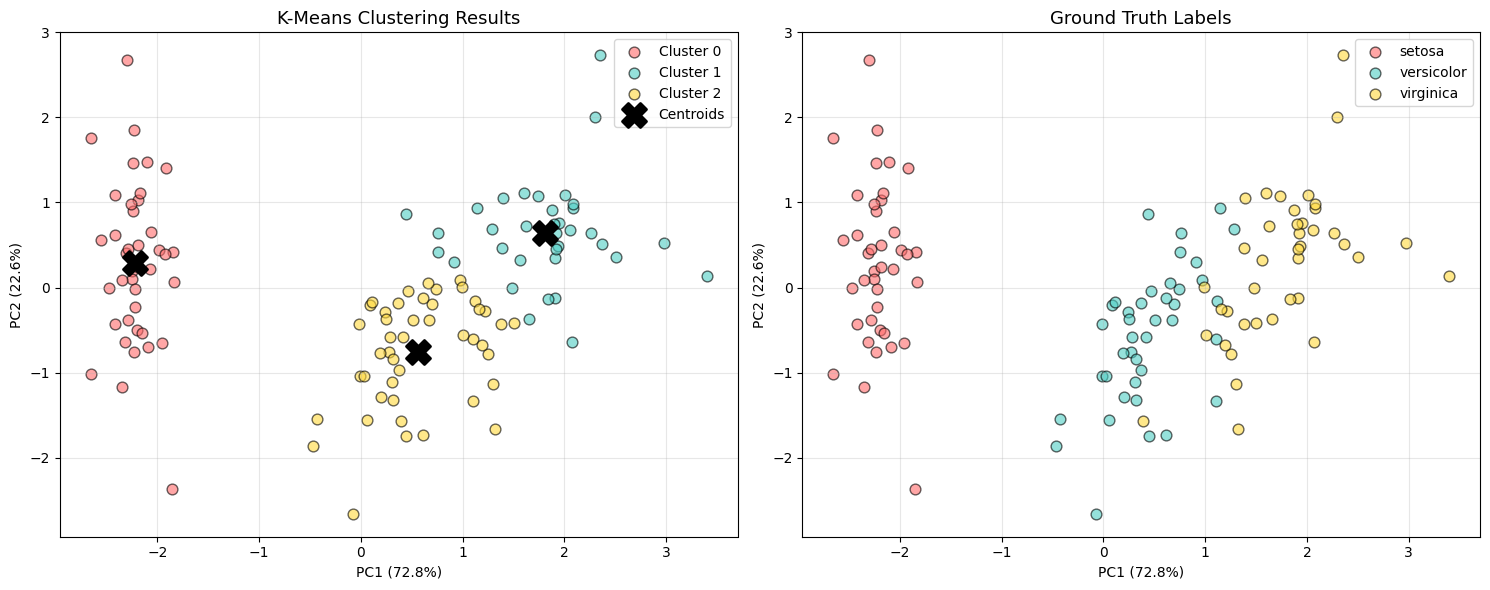


✅ 项目完成！


In [35]:
"""
项目：鸢尾花数据集的完整聚类分析流程
目标：从原始数据到最终模型评估，演示 sklearn 标准工作流
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score,
    adjusted_rand_score
)

# ============ STEP 1: 加载数据 ============
print("=" * 60)
print("STEP 1: 加载并探索数据")
print("=" * 60)

iris = load_iris()
X = iris.data
y = iris.target  # 真实标签（聚类时不用，最后验证用）

print(f"数据形状: {X.shape}")
print(f"特征名称: {iris.feature_names}")
print(f"类别名称: {iris.target_names}")
print(f"各类样本数: {np.bincount(y)}")  # [50 50 50]

# ============ STEP 2: 数据划分 ============
print("\n" + "=" * 60)
print("STEP 2: 数据集划分")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)
print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")

# ============ STEP 3: 数据预处理 ============
print("\n" + "=" * 60)
print("STEP 3: 数据标准化")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"训练集均值: {X_train_scaled.mean():.4f}（接近 0）")
print(f"训练集标准差: {X_train_scaled.std():.4f}（接近 1）")

# ============ STEP 4: 寻找最佳 K ============
print("\n" + "=" * 60)
print("STEP 4: 综合评估寻找最佳 K 值")
print("=" * 60)

results = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=123)
    km.fit(X_train_scaled)
    
    sil = silhouette_score(X_train_scaled, km.labels_)
    ch = calinski_harabasz_score(X_train_scaled, km.labels_)
    inertia = km.inertia_
    
    results.append({
        'K': k,
        '轮廓系数': sil,
        'CH指数': ch,
        '簇内平方和': inertia
    })

result_df = pd.DataFrame(results)
print(result_df.to_string(index=False))

# ============ STEP 5: 训练最终模型 ============
print("\n" + "=" * 60)
print("STEP 5: 用最佳 K=3 训练最终模型")
print("=" * 60)

final_model = KMeans(n_clusters=3, n_init=10, random_state=123)
final_model.fit(X_train_scaled)

train_labels = final_model.labels_
test_labels  = final_model.predict(X_test_scaled)

print(f"聚类中心:\n{final_model.cluster_centers_}")
print(f"迭代次数: {final_model.n_iter_}")

# ============ STEP 6: 评估模型 ============
print("\n" + "=" * 60)
print("STEP 6: 模型评估")
print("=" * 60)

# 内部指标（无需真实标签）
sil_train = silhouette_score(X_train_scaled, train_labels)
sil_test  = silhouette_score(X_test_scaled, test_labels)
print(f"训练集轮廓系数: {sil_train:.4f}")
print(f"测试集轮廓系数: {sil_test:.4f}")

# 外部指标（对比真实标签——调整兰德指数）
ari_train = adjusted_rand_score(y_train, train_labels)
ari_test  = adjusted_rand_score(y_test, test_labels)
print(f"训练集 ARI: {ari_train:.4f}（越接近 1 越好）")
print(f"测试集 ARI: {ari_test:.4f}")

# ============ STEP 7: 可视化结果 ============
print("\n" + "=" * 60)
print("STEP 7: PCA 降维可视化")
print("=" * 60)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
centers_pca = pca.transform(final_model.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左图：聚类结果
ax1 = axes[0]
colors = ['#FF6B6B', '#4ECDC4', '#FFD93D']
for i in range(3):
    mask = train_labels == i
    ax1.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}', 
                alpha=0.6, edgecolors='black', s=60)
ax1.scatter(centers_pca[:, 0], centers_pca[:, 1],
            c='black', marker='X', s=300, linewidths=2, label='Centroids')
ax1.set_title('K-Means Clustering Results', fontsize=13)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax1.legend()
ax1.grid(alpha=0.3)

# 右图：真实标签
ax2 = axes[1]
for i in range(3):
    mask = y_train == i
    ax2.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                c=colors[i], label=iris.target_names[i],
                alpha=0.6, edgecolors='black', s=60)
ax2.set_title('Ground Truth Labels', fontsize=13)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('iris_clustering_result.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ 项目完成！")